# 

In [48]:
'''Major Project – General health prediction from CVD.csv

1.	Split dataset with 8:2 ratio for train and test sets
2.	Apply SVM, Random forest and Logistic regression for building model (use X_train, Y-train)
3.	Test the models one by one on unseen data (X_test)
4.	Display accuracy score, classification report and confusion matrix for each of models
5.	Plot the comparison of the accuracies as a bar chart
6.	Apply randomised grid search to tune the hyper parameters
7.	Predict and display the health status for a single input from the dataset resembling the working of an AI system

DO it in google colab and submit it as .ipynb

'''


'Major Project – General health prediction from CVD.csv\n\n1.\tSplit dataset with 8:2 ratio for train and test sets\n2.\tApply SVM, Random forest and Logistic regression for building model (use X_train, Y-train)\n3.\tTest the models one by one on unseen data (X_test)\n4.\tDisplay accuracy score, classification report and confusion matrix for each of models\n5.\tPlot the comparison of the accuracies as a bar chart\n6.\tApply randomised grid search to tune the hyper parameters\n7.\tPredict and display the health status for a single input from the dataset resembling the working of an AI system\n\nDO it in google colab and submit it as .ipynb\n\n'

In [49]:
import pandas as pd
data=pd.read_csv("CVD_cleaned.csv")
df=pd.DataFrame(data)
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       308854 non-null  object 
 2   Exercise                      308854 non-null  object 
 3   Heart_Disease                 308854 non-null  object 
 4   Skin_Cancer                   308854 non-null  object 
 5   Other_Cancer                  308854 non-null  object 
 6   Depression                    308854 non-null  object 
 7   Diabetes                      308854 non-null  object 
 8   Arthritis                     308854 non-null  object 
 9   Sex                           308854 non-null  object 
 10  Age_Category                  308854 non-null  object 
 11  Height_(cm)                   308854 non-null  int64  
 12  Weight_(kg)                   308854 non-nul

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0


In [50]:
#2. Apply SVM, Random Forest and Logistic Regression

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("CVD_cleaned.csv")
X = data.drop('General_Health', axis=1)
Y = data['General_Health']
X = pd.get_dummies(X, drop_first=True)# i use it to convert string to numbers
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, Y_train)
print("logistic model is train")


logistic model is train


In [51]:
from sklearn.ensemble import RandomForestClassifier
randmodel= RandomForestClassifier(random_state=42)
randmodel.fit(X_train, Y_train)
print("randomforest model is trained")


randomforest model is trained


In [52]:
from sklearn.svm import LinearSVC
lsvc = LinearSVC(max_iter=5000, class_weight="balanced")
lsvc.fit(X_train_scaled, Y_train)
pred_svm = lsvc.predict(X_test_scaled)
print("svm model is trained")'''later i got warning while make confusion matrix of svm model thats why i 
used weight class'''

svm model is trained


In [53]:
#3.	Test the models one by one on unseen data (X_test)
prediction_logistic = model.predict(X_test_scaled)
print("Logistic Regression prediction completed")
pred_random = randmodel.predict(X_test)
print("Random Forest prediction completed")
pred_svm = lsvc.predict(X_test_scaled)
print("SVM prediction completed")

Logistic Regression prediction completed
Random Forest prediction completed
SVM prediction completed


In [54]:
print(f"logistic prediction:{prediction_logistic[:10]}done\n")
print(f"random forest prediction:{pred_random[:10]}done\n")
print(f"svm prediction:{pred_svm[:10]}done")

      

      
      

logistic prediction:['Very Good' 'Very Good' 'Good' 'Very Good' 'Good' 'Very Good' 'Very Good'
 'Very Good' 'Very Good' 'Good']done

random forest prediction:['Very Good' 'Very Good' 'Very Good' 'Excellent' 'Fair' 'Very Good'
 'Very Good' 'Very Good' 'Excellent' 'Good']done

svm prediction:['Very Good' 'Very Good' 'Poor' 'Excellent' 'Poor' 'Very Good' 'Very Good'
 'Very Good' 'Very Good' 'Good']done


Logistic Regression Accuracy: 0.427287885901151
logistic prediction classification report:              precision    recall  f1-score   support

   Excellent       0.47      0.13      0.21     11339
        Fair       0.38      0.13      0.20      7166
        Good       0.41      0.44      0.42     18784
        Poor       0.41      0.06      0.10      2265
   Very Good       0.44      0.70      0.54     22217

    accuracy                           0.43     61771
   macro avg       0.42      0.29      0.29     61771
weighted avg       0.43      0.43      0.39     61771


logistic prediction confusion matrix:[[ 1491    27  1380     2  8439]
 [   64   956  4114   102  1930]
 [  465   714  8212    65  9328]
 [   12   580  1219   128   326]
 [ 1145   220  5230    15 15607]]



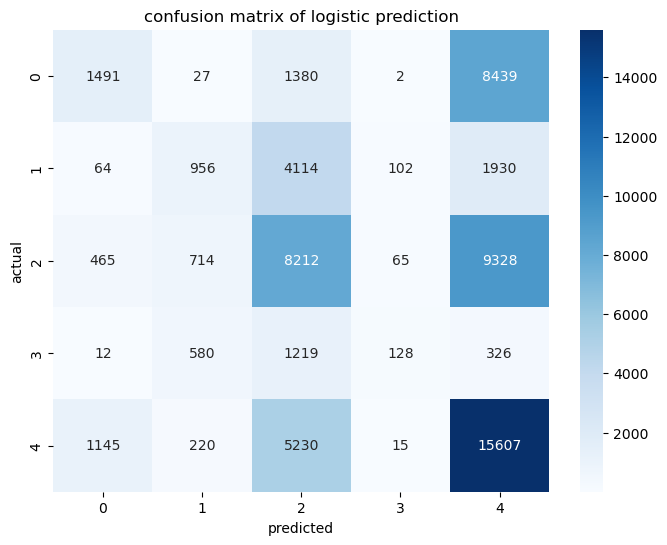

In [55]:
#4.Display accuracy score, classification report and confusion matrix for each of models
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
logistic_accuracy=accuracy_score(Y_test,prediction_logistic)
print("Logistic Regression Accuracy:", logistic_accuracy)
print(f"logistic prediction classification report:{classification_report(Y_test,prediction_logistic)}\n")
confumat_logistic=confusion_matrix(Y_test,prediction_logistic)
print(f"logistic prediction confusion matrix:{confumat_logistic}\n")
plt.figure(figsize=(8,6))
sns.heatmap(confumat_logistic,annot=True,fmt="d",cmap="Blues")
plt.title("confusion matrix of logistic prediction")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()



random forest Accuracy: 0.4079098606142041
logistic prediction classification report:              precision    recall  f1-score   support

   Excellent       0.40      0.23      0.29     11339
        Fair       0.35      0.18      0.23      7166
        Good       0.39      0.46      0.42     18784
        Poor       0.33      0.07      0.12      2265
   Very Good       0.44      0.56      0.49     22217

    accuracy                           0.41     61771
   macro avg       0.38      0.30      0.31     61771
weighted avg       0.40      0.41      0.39     61771


logistic prediction confusion matrix:[[ 2648   104  2151    10  6426]
 [  169  1266  3864   180  1687]
 [ 1109  1153  8718   110  7694]
 [   34   659  1125   161   286]
 [ 2693   458  6632    30 12404]]



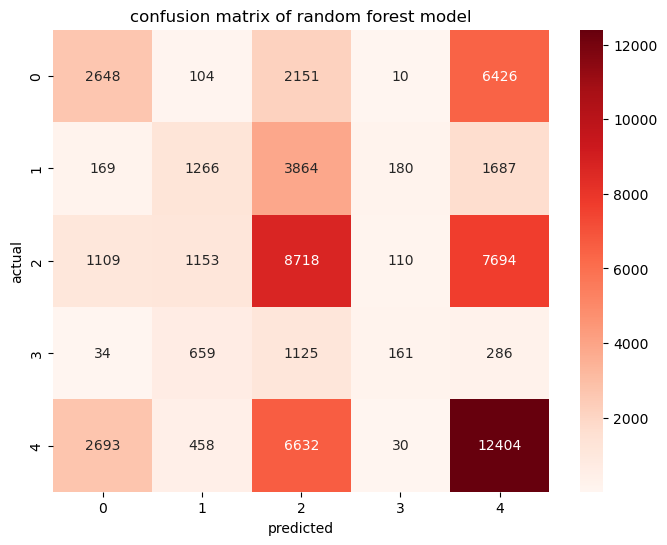

In [64]:

random_accuracy=accuracy_score(Y_test,pred_random)
print("random forest Accuracy:", random_accuracy)
print(f"logistic prediction classification report:{classification_report(Y_test,pred_random)}\n")
confumat_random=confusion_matrix(Y_test,pred_random)
print(f"logistic prediction confusion matrix:{confumat_random}\n")
plt.figure(figsize=(8,6))
sns.heatmap(confumat_random,annot=True,fmt="d",cmap="Reds")
plt.title("confusion matrix of random forest model")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()



svm Accuracy: 0.35613799355684705
logistic prediction classification report:              precision    recall  f1-score   support

   Excellent       0.35      0.51      0.41     11339
        Fair       0.26      0.22      0.24      7166
        Good       0.41      0.21      0.28     18784
        Poor       0.14      0.56      0.23      2265
   Very Good       0.45      0.42      0.44     22217

    accuracy                           0.36     61771
   macro avg       0.32      0.38      0.32     61771
weighted avg       0.39      0.36      0.35     61771


logistic prediction confusion matrix:[[5743  253  943  404 3996]
 [ 607 1544 1367 2422 1226]
 [3341 2475 4017 3078 5873]
 [  87  454  257 1278  189]
 [6691 1221 3187 1701 9417]]



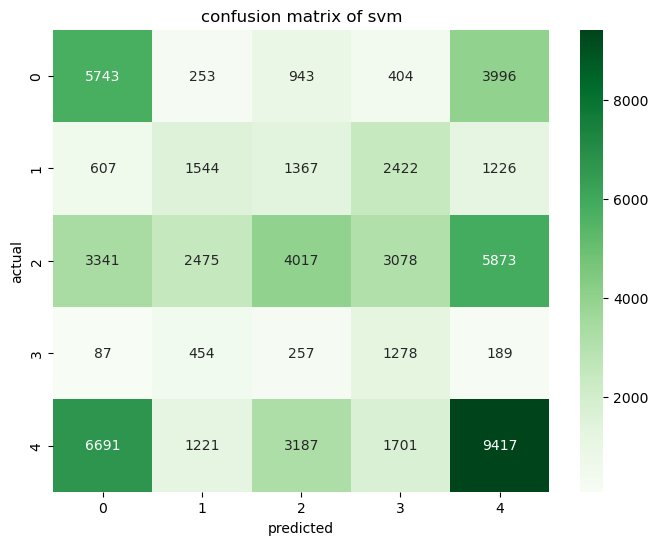

In [60]:

svm_accuracy=accuracy_score(Y_test,pred_svm)
print("svm Accuracy:", svm_accuracy)
print(f"logistic prediction classification report:{classification_report(Y_test,pred_svm)}\n")
confumat_svm=confusion_matrix(Y_test,pred_svm)
print(f"logistic prediction confusion matrix:{confumat_svm}\n")
plt.figure(figsize=(8,6))
sns.heatmap(confumat_svm,annot=True,fmt="d",cmap="Greens")
plt.title("confusion matrix of svm")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()



In [61]:
print(pd.Series(pred_svm).value_counts())

Very Good    20701
Excellent    16469
Good          9771
Poor          8883
Fair          5947
Name: count, dtype: int64


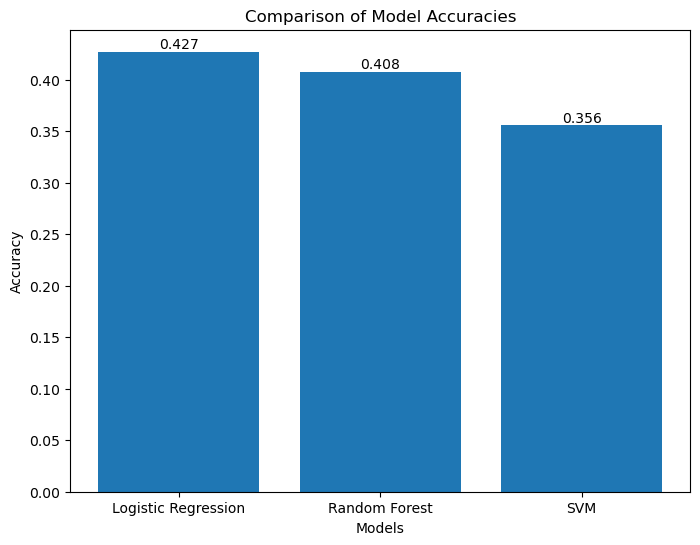

In [69]:
#5.	Plot the comparison of the accuracies as a bar chart
models = ["Logistic Regression","Random Forest","SVM"]
accuracies = [ logistic_accuracy, random_accuracy,svm_accuracy]
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
bars=plt.bar(models,accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Comparison of Model Accuracies")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}", ha="center",va="bottom")


In [71]:

print("Logistic Regression:", logistic_accuracy)
print("Random Forest:", random_accuracy)
print("SVM:", svm_accuracy)

Logistic Regression: 0.427287885901151
Random Forest: 0.4079098606142041
SVM: 0.35613799355684705


In [72]:
#6.Apply randomised grid search to tune the hyper parameters
from sklearn.model_selection import RandomizedSearchCV
logistic_params = { 'C': [0.01, 0.1, 1, 10, 100],'solver': ['lbfgs', 'liblinear']}
random_logistic = RandomizedSearchCV( model, param_distributions=logistic_params,  n_iter=5,
    cv=3, scoring='accuracy', random_state=42, n_jobs=-1)
random_logistic.fit(X_train_scaled, Y_train)
print("Best Logistic Regression Parameters:")
print(random_logistic.best_params_)

print("Best Logistic Regression Score:")
print(random_logistic.best_score_)


Best Logistic Regression Parameters:
{'solver': 'lbfgs', 'C': 100}
Best Logistic Regression Score:
0.42545622321244275


In [76]:
randomforest_params = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
random_forest_search = RandomizedSearchCV(randmodel,param_distributions=randomforest_params, n_iter=5,
    cv=3,scoring='accuracy',random_state=42,n_jobs=-1)
random_forest_search.fit(X_train, Y_train)
print("Best Random Forest Parameters:")
print(random_forest_search.best_params_)
print("Best Random Forest Score:")
print(random_forest_search.best_score_)

Best Random Forest Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}
Best Random Forest Score:
0.42472367584981563


In [81]:
svm_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}
random_svm = RandomizedSearchCV(lsvc,param_distributions=svm_params,n_iter=5,cv=3,scoring='accuracy',
    random_state=42, n_jobs=-1)
random_svm.fit(X_train_scaled, Y_train)
print("Best SVM Parameters:")
print(random_svm.best_params_)
print("Best SVM Score:")
print(random_svm.best_score_)

Best SVM Parameters:
{'C': 0.001}
Best SVM Score:
0.3558601765398672


In [82]:
#7.	Predict and display the health status for a single input from
#the dataset resembling the working of an AI system
print("logistic regression:",random_logistic.best_score_)
print("random forest:",random_forest_search.best_score_)
print("SVM:", random_svm.best_score_)


logistic regression: 0.42545622321244275
random forest: 0.42472367584981563
SVM: 0.3558601765398672


In [89]:
import warnings as warn
warn.filterwarnings("ignore")
best_model=random_logistic
single_input=X_test.iloc[[0]]
print("input data")
print(single_input)
prediction=best_model.predict(single_input)
print("predicted health status:",prediction[0])
actual=Y_test.iloc[0]
print("actual health status:",actual)
print("predicted health status:",prediction[0])
print("    GENERAL HEALTH PREDICTION AI SYSTEM   ")
single_input=X_test.iloc[[0]]
print(f"patent information:{single_input.to_string(index=False)}\n")
prediction=best_model.predict(single_input)[0]
actual=Y_test.iloc[0]
print("AI prediction health status:",prediction)
print("Actual Health Status       :", actual)

if prediction==actual:
    print('Prediction result : Correct')
else:
    print('Prediction result : Incorrect')






input data
        Height_(cm)  Weight_(kg)    BMI  Alcohol_Consumption  \
302051          178        86.18  27.26                   12   

        Fruit_Consumption  Green_Vegetables_Consumption  \
302051                 30                            16   

        FriedPotato_Consumption  Checkup_Never  \
302051                        8          False   

        Checkup_Within the past 2 years  Checkup_Within the past 5 years  ...  \
302051                            False                            False  ...   

        Age_Category_40-44  Age_Category_45-49  Age_Category_50-54  \
302051               False               False               False   

        Age_Category_55-59  Age_Category_60-64  Age_Category_65-69  \
302051               False                True               False   

        Age_Category_70-74  Age_Category_75-79  Age_Category_80+  \
302051               False               False             False   

        Smoking_History_Yes  
302051                False 

In [90]:
#a better way to represent
import warnings as warn
warn.filterwarnings("ignore")
best_model = random_logistic
single_input = X_test.iloc[[0]]
print("Input Data:")
print(single_input)
prediction = best_model.predict(single_input)

print("Predicted Health Status:", prediction[0])
actual = Y_test.iloc[0]

print("Actual Health Status:", actual)
print("Predicted Health Status:", prediction[0])
print("==============================================")
print("       GENERAL HEALTH PREDICTION AI")
print("==============================================")

single_input = X_test.iloc[[0]]

print("\nPatient Information:")
print(single_input.to_string(index=False))

prediction = best_model.predict(single_input)[0]
actual = Y_test.iloc[0]

print("\n----------------------------------------------")
print("AI Predicted Health Status :", prediction)
print("Actual Health Status       :", actual)

if prediction == actual:
    print("Prediction Result          : CORRECT")
else:
    print("Prediction Result          : INCORRECT")

print("==============================================")

Input Data:
        Height_(cm)  Weight_(kg)    BMI  Alcohol_Consumption  \
302051          178        86.18  27.26                   12   

        Fruit_Consumption  Green_Vegetables_Consumption  \
302051                 30                            16   

        FriedPotato_Consumption  Checkup_Never  \
302051                        8          False   

        Checkup_Within the past 2 years  Checkup_Within the past 5 years  ...  \
302051                            False                            False  ...   

        Age_Category_40-44  Age_Category_45-49  Age_Category_50-54  \
302051               False               False               False   

        Age_Category_55-59  Age_Category_60-64  Age_Category_65-69  \
302051               False                True               False   

        Age_Category_70-74  Age_Category_75-79  Age_Category_80+  \
302051               False               False             False   

        Smoking_History_Yes  
302051                False